In [15]:
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

In [ ]:
# Bulk

In [3]:
pretrain_bulk = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/bulk/pretraining_bulk_binned.h5ad")

In [4]:
pretrain_bulk.X.mean(axis = 1).mean()

0.24680126032860497

In [5]:
pretrain_bulk.X.getnnz(axis=1).mean()

2104.3175214285716

In [6]:
x = pretrain_bulk.X

zero_count = x.shape[0] * x.shape[1] - x.nnz
counts = {0: zero_count}

vals, freqs = np.unique(x.data, return_counts=True)
for v, c in zip(vals, freqs):
    counts[int(v)] = int(c)

rel_freq = (
    pd.Series(counts)
    .sort_index()
    .div(x.shape[0] * x.shape[1])
)

rel_freq

0    0.824113
1    0.127310
2    0.033050
3    0.010378
4    0.003491
5    0.001658
dtype: float64

[ 747 2494 2822 1923 2413 2551 2474 2491 2243 1763]
mean: 2104.3175214285716
median: 2241.0
min: 1
max: 4950


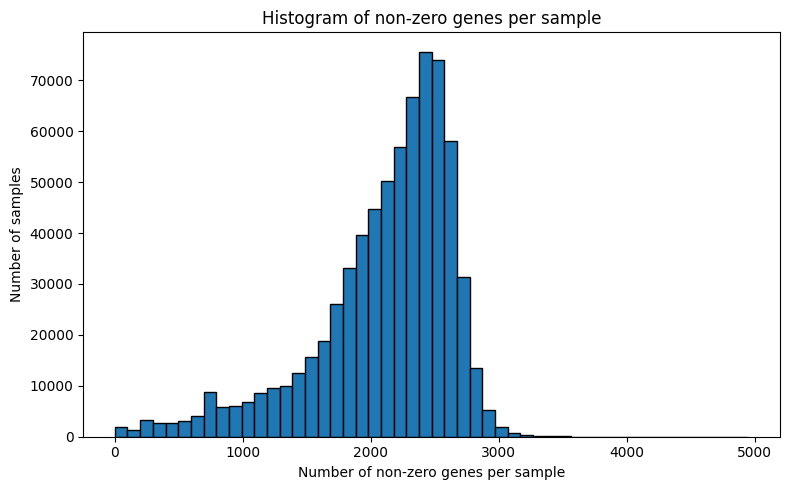

In [19]:
X = pretrain_bulk.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [ ]:
## Bulk - GTEx

In [7]:
pretrain_bulk_gtex = pretrain_bulk.copy()[pretrain_bulk.obs["dataset"] == "GTEx"]

In [8]:
pretrain_bulk_gtex.X.mean(axis = 1).mean()

0.24879354293188585

In [9]:
pretrain_bulk_gtex.X.getnnz(axis=1).mean()

2214.653438717822

In [10]:
x = pretrain_bulk_gtex.X

zero_count = x.shape[0] * x.shape[1] - x.nnz
counts = {0: zero_count}

vals, freqs = np.unique(x.data, return_counts=True)
for v, c in zip(vals, freqs):
    counts[int(v)] = int(c)

rel_freq = (
    pd.Series(counts)
    .sort_index()
    .div(x.shape[0] * x.shape[1])
)

rel_freq

0    0.814890
1    0.140390
2    0.031212
3    0.009380
4    0.002801
5    0.001327
dtype: float64

[ 747 2494 2822 1923 2413 2551 2474 2491 2243 1763]
mean: 2214.653438717822
median: 2275.0
min: 345
max: 3197


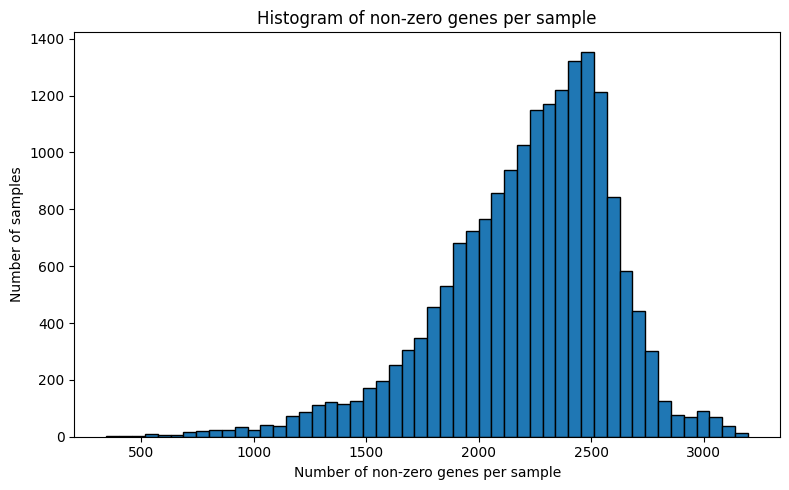

In [22]:
X = pretrain_bulk_gtex.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [ ]:
## Bulk - ARCHS4

In [24]:
pretrain_bulk_archs4 = pretrain_bulk.copy()[pretrain_bulk.obs["dataset"] == "ARCHS4"]

In [25]:
pretrain_bulk_archs4.X.mean(axis = 1).mean()

0.2467480212434014

In [26]:
pretrain_bulk_archs4.X.getnnz(axis=1).mean()

2101.3690525256643

In [27]:
x = pretrain_bulk_archs4.X

zero_count = x.shape[0] * x.shape[1] - x.nnz
counts = {0: zero_count}

vals, freqs = np.unique(x.data, return_counts=True)
for v, c in zip(vals, freqs):
    counts[int(v)] = int(c)

rel_freq = (
    pd.Series(counts)
    .sort_index()
    .div(x.shape[0] * x.shape[1])
)

rel_freq

0    0.824359
1    0.126960
2    0.033099
3    0.010405
4    0.003510
5    0.001667
dtype: float64

[2428 2455 2447 2447 2435   69   79   77   57   62]
mean: 2101.3690525256643
median: 2239.0
min: 1
max: 4950


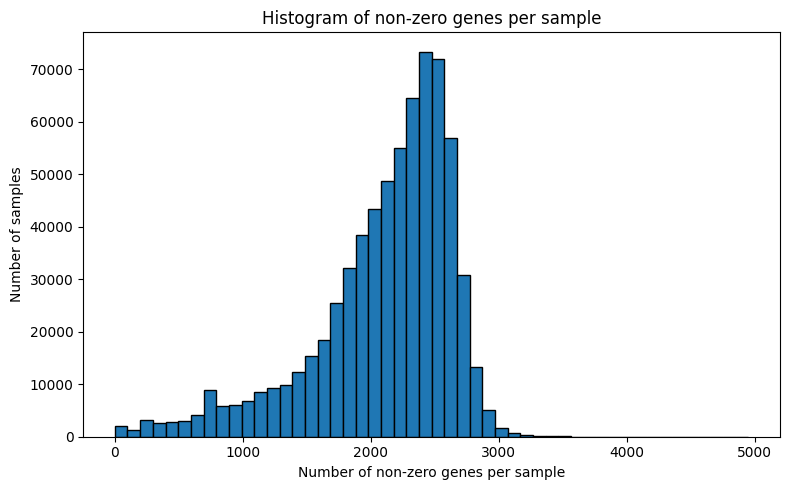

In [29]:
X = pretrain_bulk_archs4.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [33]:
# Panglao (scBERT)

In [32]:
panglao = ad.read_h5ad("/cluster/customapps/biomed/boeva/eheiss/downloads/panglao_human.h5ad")

/cluster/home/eheiss/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [34]:
panglao.X.mean(axis = 1).mean() 

0.14656486

In [35]:
panglao.X.getnnz(axis=1).mean()

1103.0902162872082

In [36]:
x = panglao.X

counts = pd.Series(0, index=range(6), dtype=np.int64)

# implicit zeros from sparsity
counts[0] = x.shape[0] * x.shape[1] - x.nnz

# explicit stored values
vals, freqs = np.unique(x.data, return_counts=True)
for v, c in zip(vals, freqs):
    v = int(v)
    if 0 <= v <= 5:
        counts[v] += int(c)

rel_freq = counts / (x.shape[0] * x.shape[1])
rel_freq

0    0.946894
1    0.022465
2    0.015027
3    0.007227
4    0.004236
5    0.002973
dtype: float64

[1567 1728 1025 2061 2062 3185 1910 2288 2946 2244]
mean: 1103.0902162872082
median: 776.0
min: 76
max: 5276


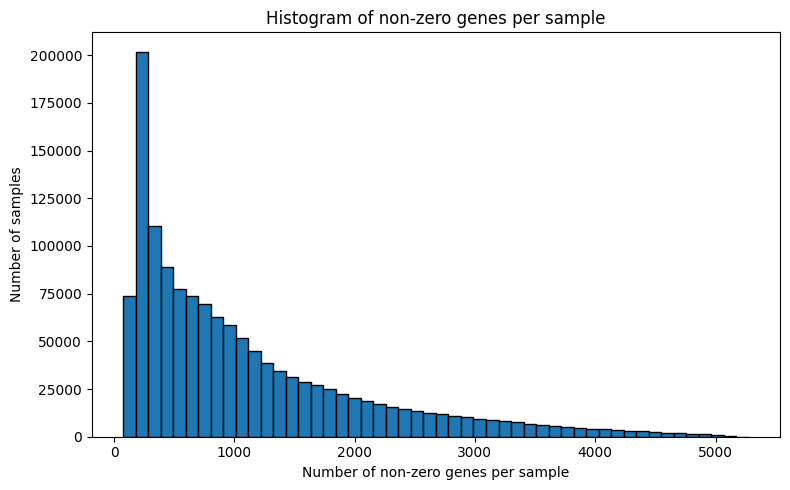

In [37]:
X = panglao.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [ ]:
# SC

In [39]:
pretrain_sc = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/sc/pretraining_sc_binned.h5ad")

In [40]:
pretrain_sc.X.mean(axis = 1).mean()

0.22112946052443044

In [41]:
pretrain_sc.X.getnnz(axis=1).mean()

1382.4040242857143

In [42]:
x = pretrain_sc.X

zero_count = x.shape[0] * x.shape[1] - x.nnz
counts = {0: zero_count}

vals, freqs = np.unique(x.data, return_counts=True)
for v, c in zip(vals, freqs):
    counts[int(v)] = int(c)

rel_freq = (
    pd.Series(counts)
    .sort_index()
    .div(x.shape[0] * x.shape[1])
)

rel_freq

0    0.884453
1    0.051245
2    0.037203
3    0.016754
4    0.006508
5    0.003837
dtype: float64

[1022 1242  435 1212 1217  537  378  847 1738 1302]
mean: 1382.4040242857143
median: 1295.0
min: 57
max: 5334


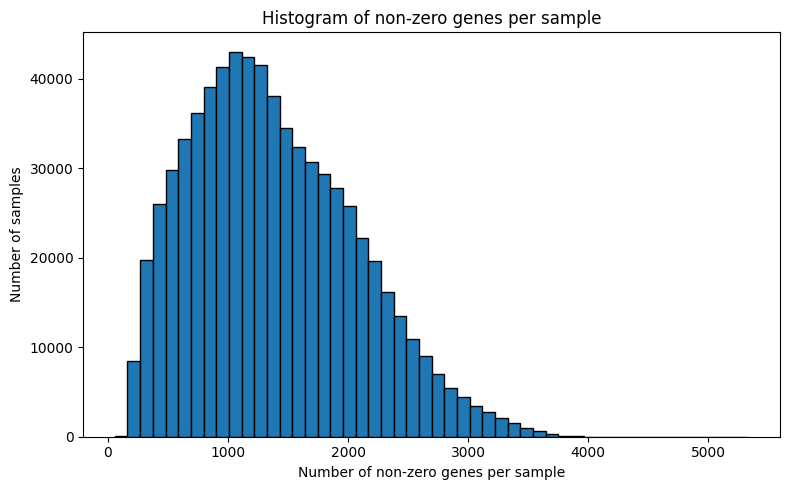

In [43]:
X = pretrain_sc.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [ ]:
# Pseudo Bulk

In [3]:
pseudo_bulk = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/pseudo_bulk/pseudo_bulk_binned.h5ad")

In [4]:
pseudo_bulk.X.mean(axis = 1).mean()

0.22172052407221662

In [5]:
pseudo_bulk.X.getnnz(axis=1).mean()

1813.52535

In [6]:
x = pseudo_bulk.X

zero_count = x.shape[0] * x.shape[1] - x.nnz
counts = {0: zero_count}

vals, freqs = np.unique(x.data, return_counts=True)
for v, c in zip(vals, freqs):
    counts[int(v)] = int(c)

rel_freq = (
    pd.Series(counts)
    .sort_index()
    .div(x.shape[0] * x.shape[1])
)

rel_freq

0    0.848418
1    0.106877
2    0.029142
3    0.008837
4    0.003582
5    0.003144
dtype: float64

In [ ]:
X = pretrain_sc.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()